# Imports

In [9]:
import sys
import os

module_path = os.path.abspath(os.path.join('..', 'src'))
sys.path.insert(0, module_path)

In [10]:
import numpy as np
from matplotlib import path
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from src.models.polygons import point_in_polygon
from matplotlib import path as mpl_path

# Functions

In [11]:
def create_polygon_trace(polygon, name, color='green', width=3):
    """Create a Plotly trace for polygon outline"""
    polygon_closed = np.vstack([polygon, polygon[0]])  # Close the polygon
    return go.Scatter(
        x=polygon_closed[:, 0],
        y=polygon_closed[:, 1],
        mode='lines',
        line=dict(color=color, width=width),
        name=name,
        showlegend=True
    )

def create_scatter_trace(coords, inside_mask, inside_color='blue', outside_color='red', 
                         inside_name='Inside Polluted Area', outside_name='Outside Polluted Area', size=3, opacity=0.6):
    """Create scatter traces for inside and outside points"""
    traces = []
    
    # Outside points trace
    if np.any(~inside_mask):
        traces.append(go.Scatter(
            x=coords[~inside_mask, 0],
            y=coords[~inside_mask, 1],
            mode='markers',
            marker=dict(color=outside_color, size=size, opacity=opacity),
            name=outside_name,
            showlegend=True
        ))
    
    # Inside points trace
    if np.any(inside_mask):
        traces.append(go.Scatter(
            x=coords[inside_mask, 0],
            y=coords[inside_mask, 1],
            mode='markers',
            marker=dict(color=inside_color, size=size, opacity=opacity),
            name=inside_name,
            showlegend=True
        ))
    
    return traces

def plot_single_polygon(coords, polygon, inside_mask, title="Agent Distribution"):
    """Plot results for a single polygon"""
    fig = go.Figure()
    
    # Add scatter traces
    scatter_traces = create_scatter_trace(coords, inside_mask)
    for trace in scatter_traces:
        fig.add_trace(trace)
    
    # Add polygon trace
    poly_trace = create_polygon_trace(polygon, "Pollution Mask Polygon")
    fig.add_trace(poly_trace)
    
    # Update layout
    fig.update_layout(
        title=dict(text=title, x=0.5, xanchor='center'),
        xaxis_title="Agent X Coordinate",
        yaxis_title="Agent Y Coordinate",
        width=800,
        height=600,
        showlegend=True,
        template="plotly_white"
    )
    
    fig.update_xaxes(range=[min_coord, max_coord])
    fig.update_yaxes(range=[min_coord, max_coord], scaleanchor="x")
    
    return fig

# Generate coordinates

In [12]:
min_coord = 0
max_coord = 100
agents_number = 10000
np.random.seed(42)
x_coords = np.random.uniform(low=min_coord, high=max_coord, size=agents_number).round(decimals=2)
y_coords = np.random.uniform(low=min_coord, high=max_coord, size=agents_number).round(decimals=2)
coords = np.column_stack((x_coords, y_coords))

In [14]:
# Create individual plots
polygon_coords = [[20,20], [20,40], [40,40], [40,20]]
square_polygon = mpl_path.Path(polygon_coords)
inside_square_poly = []
for x, y in coords:
    inside_square_poly.append(point_in_polygon(x, y, square_polygon))
inside_square_poly = np.array(inside_square_poly)

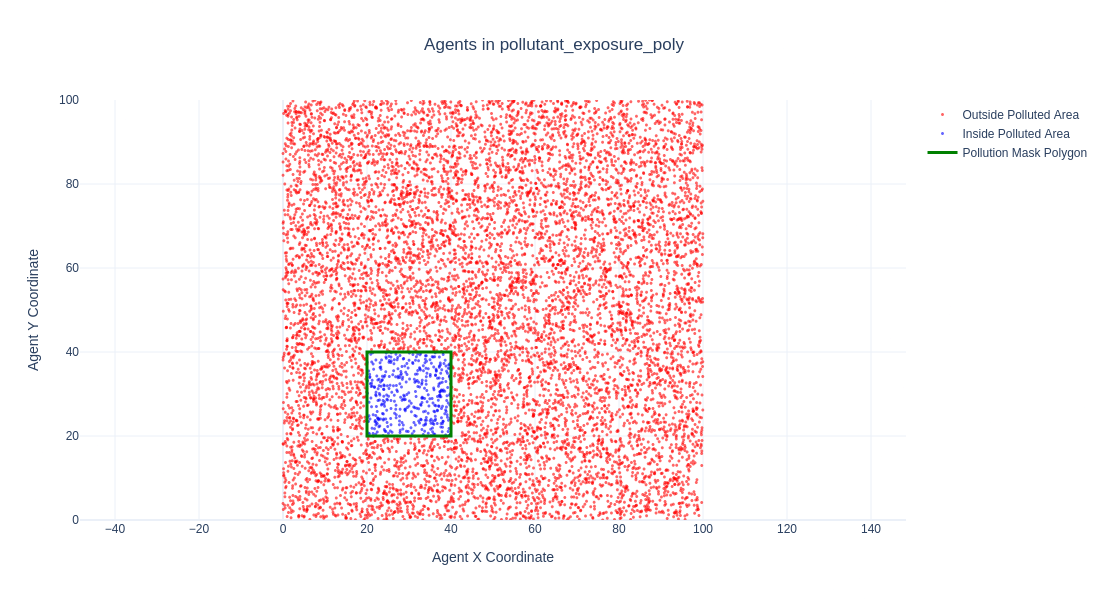

In [16]:
fig = plot_single_polygon(coords, polygon_coords, inside_square_poly, "Agents in pollutant_exposure_poly")
fig.show()